In [13]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
warnings.filterwarnings("ignore")

In [14]:
folder_path = "/media3/CRP8/TDE/data/DR_photometry_full/extragalactic/"
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
if not csv_files:
    print("No CSV files found in the folder.")
else:
    first_csv = os.path.join(folder_path, csv_files[0])
    print(f"Opening: {first_csv}")
    df = pd.read_csv(first_csv)
    headers = df.columns.tolist()
    print("Headers:", headers)

Opening: /media3/CRP8/TDE/data/DR_photometry_full/extragalactic/ZTF18abtzoip.csv
Headers: ['oid', 'expid', 'hjd', 'mjd', 'mag', 'magerr', 'catflags', 'filtercode', 'ra', 'dec', 'chi', 'sharp', 'filefracday', 'field', 'ccdid', 'qid', 'limitmag', 'magzp', 'magzprms', 'clrcoeff', 'clrcounc', 'exptime', 'airmass', 'programid']


In [15]:
data_alert = pd.read_parquet('/media3/CRP8/TDE/data/xmatch/extragalactic/')
data_alert = data_alert.groupby('objectId', sort=False, as_index=False).agg(list)
data_alert['top_class'] = [np.unique(data_alert['finkclass'].values[i]) for i in range(data_alert.shape[0])]
data_alert['ztf_id']= data_alert['objectId']
data_alert['objectId']

0      ZTF19adcfrsh
1      ZTF19abhxipr
2      ZTF18aceohig
3      ZTF18acbytzf
4      ZTF19abdshcf
           ...     
438    ZTF18abwadef
439    ZTF22abkweer
440    ZTF20acakzvi
441    ZTF18acfxxmq
442    ZTF17aabautr
Name: objectId, Length: 443, dtype: object

In [16]:
import numpy as np
import pandas as pd


classes = ['BSG*_Candidate', 'Cepheid', 'LP*_Candidate', 
           'GinCl', 'HII', 'QSO', 'Radio', 'EB*', 
           'RSG*_Candidate', 'Star', 'PulsV*', 'RRLyr', 'AGN',
           'Nova', 'GinGroup', 'Mira', 'WR*', 'V*', 'BLLac']

# if classes are the same
equiv_classes = {
    'BSG*_Candidate': ['BSG*_Candidate', 'Candidate_BSG*'],
     'BSG*_Candidate': ['BSG*_Candidate', 'BlueSG*'],
    'RSG*_Candidate': ['RSG*_Candidate', 'Candidate_RSG*'],
    'EB*': ['EB*', 'EclBin'],
    
}

masks = {cls: [] for cls in classes}

for c in csv_files:
    data = pd.read_csv(folder_path + c)
    ztf_id = c.split('/')[-1].split('.')[0]
    
    row_alert = data_alert.loc[data_alert['objectId'] == ztf_id]
    topclass = np.unique(row_alert['top_class'].explode())
    
    for cls in classes:
        check_classes = equiv_classes.get(cls, [cls])
        masks[cls].append(int(np.any([t == x for t in topclass for x in check_classes])))

tot = 0        
for cls in classes:
    masks[cls] = np.array(masks[cls])
    print(f"{cls:<20}: {np.sum(masks[cls])}")
    tot = tot + np.sum(masks[cls])
print(tot)

BSG*_Candidate      : 9
Cepheid             : 4
LP*_Candidate       : 1
GinCl               : 4
HII                 : 3
QSO                 : 16
Radio               : 2
EB*                 : 5
RSG*_Candidate      : 5
Star                : 15
PulsV*              : 2
RRLyr               : 9
AGN                 : 4
Nova                : 1
GinGroup            : 2
Mira                : 1
WR*                 : 1
V*                  : 5
BLLac               : 1
90


In [17]:
masks = {cls: [] for cls in classes}
catids_per_class = {cls: [] for cls in classes}
files = {cls: [] for cls in classes}

for c in csv_files:
    data = pd.read_csv(folder_path + c)
    ztf_id = c.split('/')[-1].split('.')[0]
    
    row_alert = data_alert.loc[data_alert['objectId'] == ztf_id]
    topclass = np.unique(row_alert['top_class'].explode())
    catid = np.unique(row_alert['cat_id'].explode())
    
    if any("Baldassare" in cat or "Seth" in cat or "Gonzalez" in cat or "beccari" in cat  or 'Fahrion' in cat for cat in catid):
        None
    else:
    
        for cls in classes:
            if np.any(topclass == cls):
                masks[cls].append(1)
                catids_per_class[cls].append(catid[0])
                files[cls].append(c)
            else:
                masks[cls].append(0)

for cls in classes:
    masks[cls] = np.array(masks[cls])
    print(f"{cls:<15}: {np.sum(masks[cls])}, cat_ids: {catids_per_class[cls]}") # 
    print(files[cls])
    print(" ")
    print(" ")

    
# # Cepheid, RR Lyrae and AGN

BSG*_Candidate : 6, cat_ids: ['Ma_369', 'Peacock_869', 'Ma_291', 'Ma_348', 'Ma_291', 'Ma_369']
['ZTF19abqgmwk.csv', 'ZTF18abhqenc.csv', 'ZTF19acejbid.csv', 'ZTF18acynqoo.csv', 'ZTF18actyfhs.csv', 'ZTF19acqkdiy.csv']
 
 
Cepheid        : 2, cat_ids: ['Fan2010_881', 'Fan2010_959']
['ZTF18abskixk.csv', 'ZTF18abjpgik.csv']
 
 
LP*_Candidate  : 1, cat_ids: ['Ma_121']
['ZTF19aavvvkv.csv']
 
 
GinCl          : 3, cat_ids: ['NGC4382_sources_2677', 'NGC4649_sources_699', 'NGC4382_sources_3353']
['ZTF20aaermdw.csv', 'ZTF18aahvhdb.csv', 'ZTF23aajibwv.csv']
 
 
HII            : 2, cat_ids: ['Ma_245', 'Ma_136']
['ZTF19aaxozth.csv', 'ZTF19abmpmwc.csv']
 
 
QSO            : 14, cat_ids: ['NGC4382_sources_2677', 'NGC4382_sources_22', 'Fan2010_823', 'NGC5866_sources_1395', 'NGC5846_sources_365', 'NGC4382_sources_653', 'NGC4382_sources_2767', 'NGC4621_sources_1673', 'NGC5866_sources_728', 'NGC4382_sources_3353', 'NGC5866_sources_904', 'NGC7339_sources_291', 'NGC5866_sources_688', 'NGC5866_sources_904']


Cepheid Variable             2 candidates -> ZTF18abskixk.csv
Eclipsing Binary             4 candidates -> ZTF18aacbiwe.csv
AGN                          2 candidates -> ZTF20abbzdsf.csv


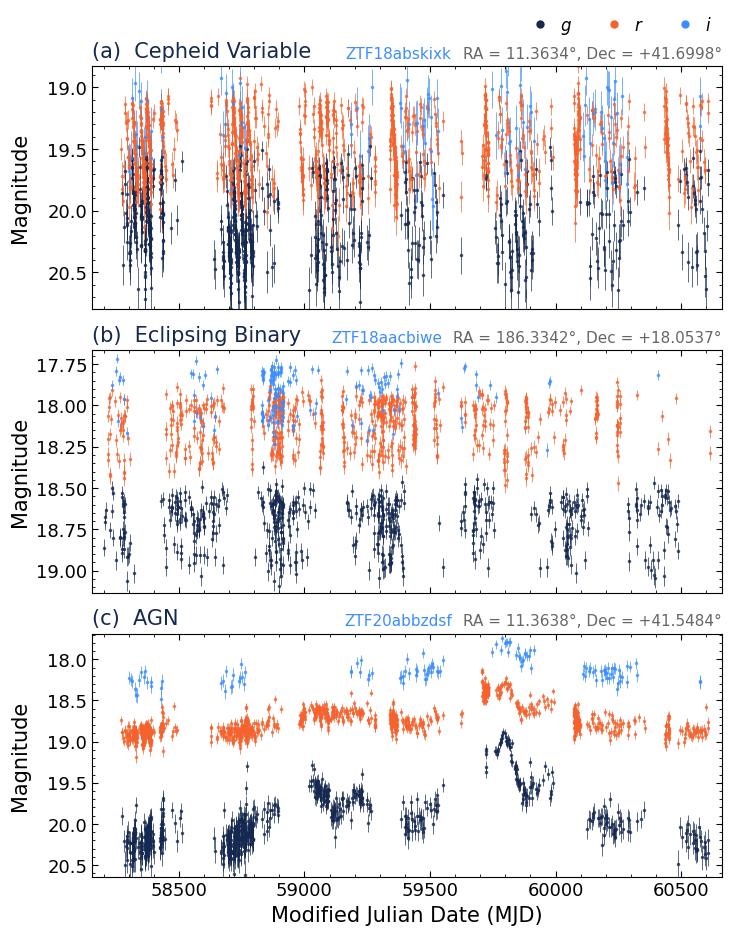

In [20]:
alerts = pd.read_parquet("/media3/CRP8/TDE/data/xmatch/extragalactic/").groupby("objectId", sort=False).agg(list)
alerts["top_class"] = alerts["finkclass"].apply(set)
alerts["cat_ids"] = alerts["cat_id"].apply(lambda v: set(pd.Series(v).explode().dropna().astype(str)))

targets = {"Cepheid Variable": {"Cepheid"}, "Eclipsing Binary": {"EB*", "EclBin"}, "AGN": {"AGN"}}
exclude = ("baldassare", "seth", "gonzalez", "beccari", "fahrion")
preferred = {"Cepheid Variable": "ZTF18abskixk.csv", "Eclipsing Binary": "ZTF18aacbiwe.csv",
             "Active Galactic Nucleus": "ZTF20abbzdsf.csv"}

candidates = {lab: [] for lab in targets}
for f in csv_files:
    zid = os.path.splitext(f)[0]
    if zid not in alerts.index:
        continue
    row = alerts.loc[zid]
    if any(k in c.lower() for c in row.cat_ids for k in exclude):
        continue
    for lab, names in targets.items():
        if row.top_class & names:
            candidates[lab].append(f)

n_good = lambda f: (pd.read_csv(folder_path + f, usecols=["catflags"])["catflags"] == 0).sum()
picks = {lab: preferred[lab] if preferred.get(lab) in fs else max(fs, key=n_good)
         for lab, fs in candidates.items() if fs}
for lab, fs in candidates.items():
    print(f"{lab:<25} {len(fs):>4} candidates -> {picks.get(lab, 'NONE FOUND')}")

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "custom", "mathtext.it": "Arial:italic", "mathtext.rm": "Arial",
    "font.size": 15, "axes.labelsize": 15, "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 10,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6, "ytick.minor.width": 0.6,
    "xtick.major.size": 4, "ytick.major.size": 4, "xtick.minor.size": 2, "ytick.minor.size": 2,
    "xtick.direction": "in", "ytick.direction": "in", "xtick.top": True, "ytick.right": True,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 600,
})

filter_map = {"zg": ("g", 1), "zr": ("r", 2), "zi": ("i", 3)}
band_colors = {1: "#15284F", 3: "#3c8dff", 2: "#f5622e"}
band_labels = {1: r"$g$", 2: r"$r$", 3: r"$i$"}

fig, axes = plt.subplots(len(picks), 1, figsize=(7.2, 9), sharex=True, constrained_layout=True, squeeze=False)
axes = axes[:, 0]
fig.get_layout_engine().set(h_pad=0.08)

for j, ((lab, f), ax) in enumerate(zip(picks.items(), axes)):
    d = pd.read_csv(folder_path + f).query("catflags == 0")
    bands = d["filtercode"].map(lambda x: filter_map[x][1]).values

    for b in np.unique(bands):
        m, c = bands == b, band_colors[b]
        ax.errorbar(d["mjd"].values[m], d["mag"].values[m], yerr=d["magerr"].values[m],
                    fmt="o", ms=2.5, mew=0, elinewidth=0.6, capsize=0,
                    color=c, ecolor=c, alpha=0.8, rasterized=True)

    lo, hi = np.nanpercentile(d["mag"], [0.5, 99.5])
    pad = 0.08 * (hi - lo)
    ax.set_ylim(hi + pad, lo - pad)

    ax.text(0.0, 1.02, f"({'abc'[j]})  {lab}", transform=ax.transAxes,
            fontsize=15,color="#15284F", va="bottom")
    # ax.text(1.0, 1.02, os.path.splitext(f)[0], transform=ax.transAxes,
    #         fontsize=9, color="0.4", va="bottom", ha="right", family="monospace")
    ax.set_ylabel("Magnitude")
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.margins(x=0.02)

    from astropy.coordinates import SkyCoord
    import astropy.units as u
    zid = os.path.splitext(f)[0]
    # s = SkyCoord(np.nanmedian(d["ra"]) * u.deg, np.nanmedian(d["dec"]) * u.deg)
    # ax.text(1.0, 1.02, f"{os.path.splitext(f)[0]}   {s.to_string('hmsdms', precision=1)}",
    #         transform=ax.transAxes, fontsize=8.5, color="0.4", va="bottom", ha="right")
    ra, dec = np.nanmedian(d["ra"]), np.nanmedian(d["dec"])
    # ax.text(1.0, 1.02, f"{os.path.splitext(f)[0]}   RA = {ra:.4f}°, Dec = {dec:+.4f}°",
    #         transform=ax.transAxes, fontsize=11, color="0.4", va="bottom", ha="right")
    coord = ax.text(1.0, 1.02, f"RA = {ra:.4f}°, Dec = {dec:+.4f}°", transform=ax.transAxes,
                    fontsize=11, color="0.4", va="bottom", ha="right",
                    url=f"https://simbad.cds.unistra.fr/simbad/sim-coo?Coord={ra}+{dec:+}&Radius=5&Radius.unit=arcsec")
    ax.annotate(zid, xy=(0, 0), xycoords=coord, xytext=(-8, 0), textcoords="offset points",
                fontsize=11, color="#3c8dff", va="bottom", ha="right",
                url=f"https://ztf.fink-portal.org/{zid}")

axes[-1].set_xlabel("Modified Julian Date (MJD)")
handles = [Line2D([0], [0], marker="o", ls="none", ms=6, mew=0, color=band_colors[b], label=band_labels[b])
           for b in (1, 2, 3)]
fig.legend(handles=handles, loc="lower center", fontsize=12,bbox_to_anchor=(0.85, 0.98), ncol=3, frameon=False,
           handletextpad=0.2, columnspacing=1.5)
fig.align_ylabels(axes)

plt.savefig("fig1lightcurves_ymctde.pdf", bbox_inches="tight", facecolor="white", dpi=250)
plt.show()